# Read Cloud Results

Load result files from `data/` (falls back to `cloud_data/`) and recreate the plots from `main_HF.ipynb`. Set `shots`, `MOLECULE`, and `BOND_LENGTH` in the first code cell to choose a run such as `data/shots_8192/Cl2_bond_2.8`.

Works with **full or incomplete** runs:
- VQE-only (no CMX yet)
- Partial CMX (some multipliers finished; pending ones skipped)
- Full CMX sweep without variance repeats (points only, no error bars)
- Full CMX with `variance_repeats >= 2` (plots empirical σ error bars from replicate CMX energies)

In [1]:
from pathlib import Path
import json
import pickle
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({"figure.dpi": 140})

# Prefer data/ (current export path); fall back to cloud_data/ if present.
_candidates = [Path("data"), Path("cloud_data")]
DATA_ROOT = next((p for p in _candidates if p.is_dir()), _candidates[0])

# Choose which fetched cloud run to read.
shots = 8192  # e.g. 8192 -> data/shots_8192, 81920 -> data/shots_81920
MOLECULE = "HF"
BOND_LENGTH = 2.2
SHOTS_DIR = DATA_ROOT / f"shots_{shots}"
RUN_DIR = SHOTS_DIR / f"{MOLECULE}_bond_{BOND_LENGTH:.1f}"

print(f"DATA_ROOT: {DATA_ROOT.resolve()}")
shot_dirs = sorted(p for p in DATA_ROOT.glob("shots_*") if p.is_dir())
print("Available shot budgets:")
for i, shot_dir in enumerate(shot_dirs):
    print(f"{i}: {shot_dir}")

if not SHOTS_DIR.is_dir():
    available = ", ".join(str(p) for p in shot_dirs) or "none"
    raise FileNotFoundError(
        f"Shots directory not found: {SHOTS_DIR}. "
        f"Set shots to one of the available budgets: {available}"
    )

runs = sorted(p for p in SHOTS_DIR.glob("*_bond_*") if p.is_dir())
print(f"\nAvailable runs under {SHOTS_DIR}:")
for i, run in enumerate(runs):
    print(f"{i}: {run}")

if not RUN_DIR.is_dir():
    available = ", ".join(str(run) for run in runs) or "none"
    raise FileNotFoundError(
        f"Run directory not found: {RUN_DIR}. "
        f"Set MOLECULE/BOND_LENGTH to one of the available runs: {available}"
    )

print(f"\nSelected run: {RUN_DIR}")
RUN_DIR


DATA_ROOT: /Users/zacharyhe/cross_chips_sim/June_main/export2cloud/data
Available shot budgets:
0: data/shots_16384
1: data/shots_8192
2: data/shots_81920

Available runs under data/shots_8192:
0: data/shots_8192/Br2_bond_2.2
1: data/shots_8192/Br2_bond_3.8
2: data/shots_8192/Cl2_bond_1.2
3: data/shots_8192/Cl2_bond_1.8
4: data/shots_8192/Cl2_bond_2.0
5: data/shots_8192/Cl2_bond_2.2
6: data/shots_8192/Cl2_bond_2.4
7: data/shots_8192/Cl2_bond_2.6
8: data/shots_8192/Cl2_bond_2.8
9: data/shots_8192/Cl2_bond_3.0
10: data/shots_8192/HF_bond_1.2
11: data/shots_8192/HF_bond_1.8
12: data/shots_8192/HF_bond_2.2

Selected run: data/shots_8192/HF_bond_2.2


PosixPath('data/shots_8192/HF_bond_2.2')

In [2]:
EXPECTED_FILES = (
    "run_summary.json",
    "vqe_results.json",
    "vqe_results.pkl",
    "vqe_progress.json",
    "cme_results.json",
    "cme_results_by_multiplier.json",
    "cmx_progress.json",
    "all_results.pkl",
)


def load_json(name):
    path = RUN_DIR / name
    if not path.exists() or path.stat().st_size == 0:
        return None
    try:
        return json.loads(path.read_text())
    except json.JSONDecodeError:
        print(f"Warning: {path.name} exists but is not valid JSON; ignoring.")
        return None


def load_pickle(name):
    path = RUN_DIR / name
    if not path.exists() or path.stat().st_size == 0:
        return None
    with path.open("rb") as handle:
        return pickle.load(handle)


def as_float_array(records, key):
    return np.asarray([float(row[key]) for row in records], dtype=float)


def _finite(x):
    try:
        return np.isfinite(float(x))
    except (TypeError, ValueError):
        return False


def cmx_entry_has_errorbar(entry):
    """True when replicate CMX energies support an empirical σ error bar."""
    if entry is None:
        return False
    reps = entry.get("E_cme_replicates") or []
    n_reps = len(reps) if isinstance(reps, list) else 0
    repeats = int(entry.get("variance_repeats") or n_reps or 0)
    emp = entry.get("E_cme_empirical_sigma")
    if repeats >= 2 and _finite(emp) and float(emp) >= 0:
        return True
    if n_reps >= 2:
        return True
    return False


def inventory_run_dir():
    print("Run file inventory:")
    for name in EXPECTED_FILES:
        path = RUN_DIR / name
        if not path.exists():
            status = "missing"
        elif path.stat().st_size == 0:
            status = "empty"
        else:
            status = f"ok ({path.stat().st_size:,} B)"
        print(f"  {name:<36} {status}")


inventory_run_dir()

summary = load_json("run_summary.json") or {}
vqe_results = load_json("vqe_results.json")
if vqe_results is None:
    vqe_results = load_pickle("vqe_results.pkl")
    if vqe_results is not None:
        print("Loaded VQE results from vqe_results.pkl (JSON missing or empty).")

cme_results = load_json("cme_results.json")
if cme_results is None:
    cme_results = load_pickle("cme_results.pkl")

cme_by_multiplier = load_json("cme_results_by_multiplier.json") or {}
if not cme_by_multiplier:
    cme_by_multiplier = load_pickle("cme_results_by_multiplier.pkl") or {}
# Normalize multiplier keys to int for stable sorting / lookups.
cme_by_multiplier = {int(k): v for k, v in cme_by_multiplier.items()}

cmx_progress = load_json("cmx_progress.json") or {}

molecule = summary.get("molecule", RUN_DIR.name.split("_bond_")[0])
bond_length = float(summary.get("bond_length", RUN_DIR.name.split("_bond_")[-1]))

# Exact ground-state references (Hartree) from Pauli_Ham bond scans / saved CMX runs.
KNOWN_GS_ENERGIES = {
    ("HF", 1.2): -98.57387833667892,
    ("HF", 2.2): -98.45842350054684,
    ("Cl2", 1.2): -907.2899804679435,
    ("Cl2", 1.8): -909.073706577282,
    ("Cl2", 2.0): -909.138605415526,  # Pauli_Ham/Cl2_bond_scan_summary.txt
    ("Cl2", 2.2): -909.1452968060628,
    ("Cl2", 2.4): -909.131028697872,
    ("Cl2", 2.6): -909.1136760413856,
    ("Cl2", 2.8): -909.1002543580921,
    ("Cl2", 3.0): -909.0919008958635,
    # Br2 from Pauli_Ham/Br2_bond_scan_summary.txt
    ("Br2", 2.0): -5089.281118365087,
    ("Br2", 2.2): -5089.341622316407,
    ("Br2", 2.4): -5089.348627550298,
    ("Br2", 2.6): -5089.333405467210,
    ("Br2", 2.8): -5089.312897236618,
    ("Br2", 3.0): -5089.295481923087,
    ("Br2", 3.2): -5089.283875431507,
    ("Br2", 3.4): -5089.277454104787,
    ("Br2", 3.6): -5089.274477081924,
    ("Br2", 3.8): -5089.274186708570,
}

e_ref = None
if cme_results and cme_results.get("e_gs") is not None:
    e_ref = cme_results.get("e_gs")
if e_ref is None and cme_by_multiplier:
    first_cme = next(iter(cme_by_multiplier.values()))
    e_ref = first_cme.get("e_gs")
if e_ref is None:
    e_ref = KNOWN_GS_ENERGIES.get((molecule, round(bond_length, 1)))
if e_ref is None:
    print(
        "Warning: no ground-state reference for this run. "
        "VQE error plots will be skipped; add an entry to KNOWN_GS_ENERGIES."
    )
else:
    e_ref = float(e_ref)

# Classify CMX completeness for plotting / messaging.
completed_mults = sorted(cme_by_multiplier.keys())
planned_mults = [int(x) for x in (cmx_progress.get("CME_SHOT_MULTIPLIERS") or [])]
pending_mults = [int(x) for x in (cmx_progress.get("pending_multipliers") or [])]
progress_completed = [
    int(x) for x in (cmx_progress.get("completed_multipliers") or completed_mults)
]

has_errorbars = {
    m: cmx_entry_has_errorbar(cme_by_multiplier[m]) for m in completed_mults
}
n_with_err = sum(1 for ok in has_errorbars.values() if ok)

if not completed_mults:
    cmx_status = "none (VQE-only or CMX not started)"
elif pending_mults or (planned_mults and set(completed_mults) < set(planned_mults)):
    cmx_status = (
        f"partial ({len(completed_mults)} multiplier(s) saved"
        f"{', pending=' + str(pending_mults) if pending_mults else ''})"
    )
elif n_with_err == len(completed_mults) and n_with_err > 0:
    cmx_status = (
        f"complete with error bars ({len(completed_mults)} multipliers, replicate σ)"
    )
elif n_with_err > 0:
    cmx_status = (
        f"complete sweep, mixed error bars "
        f"({n_with_err}/{len(completed_mults)} points have replicate σ)"
    )
else:
    cmx_status = (
        f"complete sweep without error bars "
        f"({len(completed_mults)} multipliers; variance_repeats < 2)"
    )

print(json.dumps(summary, indent=2))
if e_ref is not None:
    print(f"Ground-state reference: {e_ref:.12f} Eh")
print(f"Has VQE curves: {vqe_results is not None}")
print(f"Has CMX sweep: {bool(cme_by_multiplier)}")
print(f"CMX status: {cmx_status}")
if completed_mults:
    print(
        "  multipliers:",
        ", ".join(
            f"{m}x{' [σ]' if has_errorbars[m] else ''}" for m in completed_mults
        ),
    )
if cmx_progress:
    print(
        "  cmx_progress:",
        f"completed={progress_completed}, pending={pending_mults}, "
        f"planned={planned_mults}, "
        f"variance_repeats={cmx_progress.get('CME_VARIANCE_REPEATS')}",
    )


Run file inventory:
  run_summary.json                     ok (384 B)
  vqe_results.json                     ok (13,702 B)
  vqe_results.pkl                      ok (5,623 B)
  vqe_progress.json                    missing
  cme_results.json                     ok (1,207 B)
  cme_results_by_multiplier.json       ok (3,943 B)
  cmx_progress.json                    missing
  all_results.pkl                      ok (7,682 B)
{
  "bond_length": 2.2,
  "created_utc": "2026-07-11T05:15:36.825520+00:00",
  "has_cme_results": true,
  "has_cme_results_by_multiplier": true,
  "has_vqe_results": true,
  "metadata": {
    "cdr_training_circuits": 30,
    "circuit_name": "HF_8q_3doubles_rzx",
    "measurement_scheme": "ogm",
    "num_shots": 8192,
    "vqe_iters": 15
  },
  "molecule": "HF",
  "stage": "final"
}
Ground-state reference: -98.458423500547 Eh
Has VQE curves: True
Has CMX sweep: True
CMX status: complete sweep without error bars (3 multipliers; variance_repeats < 2)
  multipliers: 5x, 10

Using true GS reference energy: -98.458423500547 Eh
Best REM+CF energy: -98.475477624733 Eh
Best REM+CF error: 1.705412e-02 Eh

REM+CF energy by iteration:
  iter         REM+CF (Eh)   |E - E_GS| (Eh)
     0    -98.202944162266      2.554793e-01
     1    -98.302472887798      1.559506e-01
     2    -98.182145827821      2.762777e-01
     3    -98.178935109995      2.794884e-01
     4    -98.249956152540      2.084673e-01
     5    -98.337189203497      1.212343e-01
     6    -98.428868190226      2.955531e-02
     7    -98.270400882416      1.880226e-01
     8    -98.336392513502      1.220310e-01
     9    -98.298193984906      1.602295e-01
    10    -98.462210457955      3.786957e-03
    11    -98.371274503830      8.714900e-02
    12    -98.340256880317      1.181666e-01
    13    -98.217670126634      2.407534e-01
    14    -98.298964604601      1.594589e-01
    15    -98.475477624733      1.705412e-02


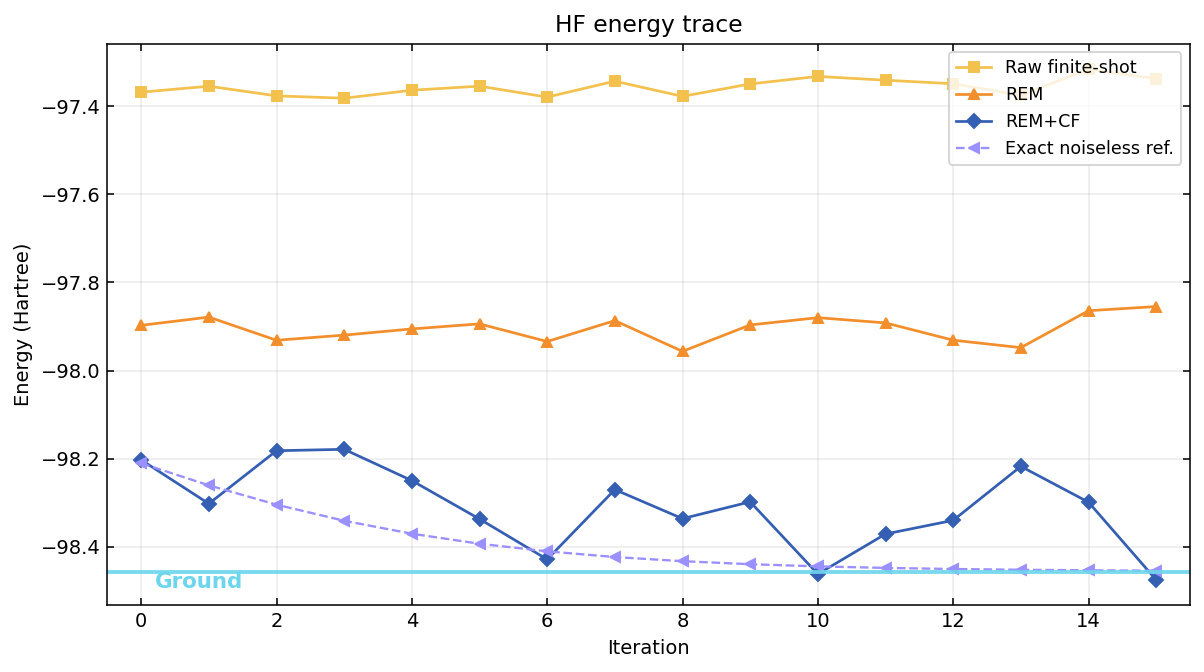

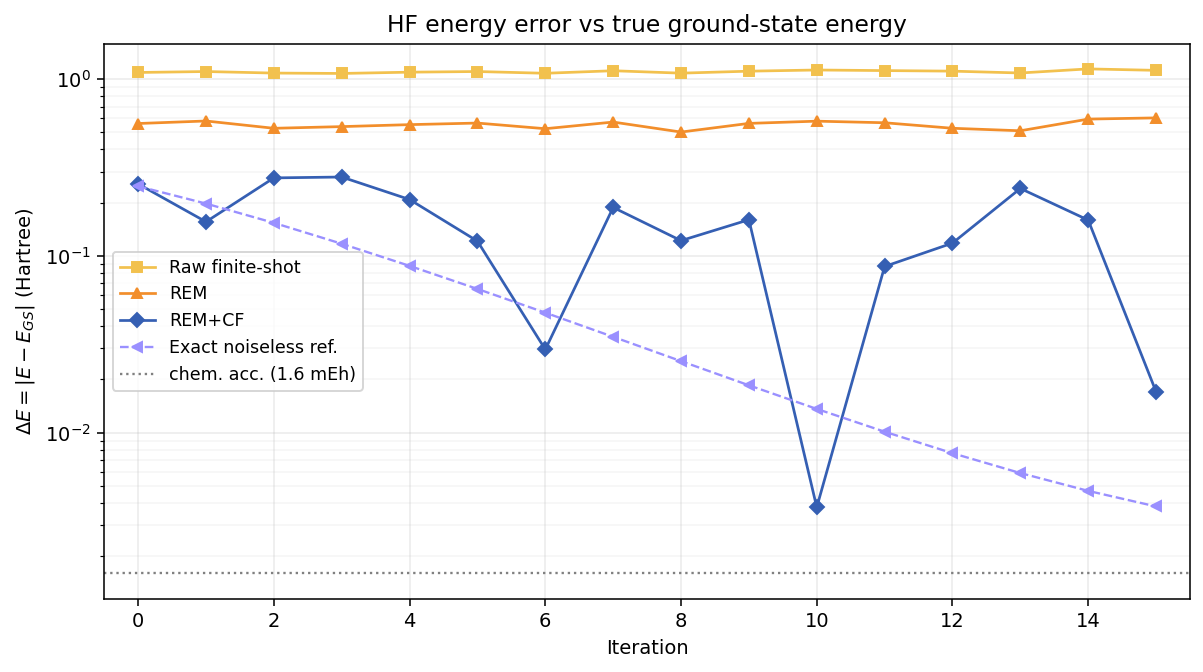

In [3]:
# --- VQE plots from saved cloud data: energy trace + log-scale error vs true GS ---
if vqe_results is None:
    print("No VQE results found in", RUN_DIR)
elif e_ref is None:
    print("Skipping VQE plots: ground-state reference unavailable for", RUN_DIR.name)
else:
    ec = vqe_results["energy_curves"]
    xs = as_float_array(ec, "iter")
    raw = as_float_array(ec, "raw_eh")
    rem = as_float_array(ec, "rem_eh")
    cf = as_float_array(ec, "rem_cf_eh")
    nls = as_float_array(ec, "noiseless_eh")

    style_raw = dict(color="#f2c14e", marker="s", ms=5, lw=1.4, label="Raw finite-shot")
    style_rem = dict(color="#f28e2b", marker="^", ms=5, lw=1.4, label="REM")
    style_cf = dict(color="#355fb3", marker="D", ms=4.8, lw=1.4, label="REM+CF")
    style_nls = dict(color="#9a90ff", marker="<", ms=5, lw=1.2, linestyle="--", label="Exact noiseless ref.")

    # ---- Energy trace ----
    fig1, ax1 = plt.subplots(figsize=(8.7, 4.9))
    ax1.plot(xs, raw, **style_raw)
    ax1.plot(xs, rem, **style_rem)
    ax1.plot(xs, cf, **style_cf)
    ax1.plot(xs, nls, **style_nls)
    ax1.axhline(e_ref, color="#6dd5ed", lw=2.0, alpha=0.9)
    ax1.text(xs.min() + 0.2, e_ref, "Ground", color="#6dd5ed", va="top", ha="left", fontsize=11, weight="bold")

    all_e = np.concatenate([raw, rem, cf, nls, [e_ref]])
    lo, hi = float(all_e.min()), float(all_e.max())
    pad = 0.05 * (hi - lo + 1e-9)
    ax1.set_xlim(xs.min() - 0.5, xs.max() + 0.5)
    ax1.set_ylim(lo - pad, hi + pad)
    ax1.tick_params(axis="both", which="both", direction="in", top=True, right=True)
    ax1.set_xlabel("Iteration")
    ax1.set_ylabel("Energy (Hartree)")
    ax1.set_title(f"{molecule} energy trace")
    ax1.grid(True, alpha=0.25)
    ax1.legend(loc="best", fontsize=9)
    fig1.tight_layout()

    # ---- Absolute error vs true GS (log-y) ----
    floor = 1e-16
    err_raw = np.maximum(np.abs(raw - e_ref), floor)
    err_rem = np.maximum(np.abs(rem - e_ref), floor)
    err_cf = np.maximum(np.abs(cf - e_ref), floor)
    err_nls = np.maximum(np.abs(nls - e_ref), floor)

    fig2, ax2 = plt.subplots(figsize=(8.7, 4.9))
    ax2.plot(xs, err_raw, **style_raw)
    ax2.plot(xs, err_rem, **style_rem)
    ax2.plot(xs, err_cf, **style_cf)
    ax2.plot(xs, err_nls, **style_nls)
    ax2.set_yscale("log")
    ax2.axhline(1.6e-3, color="gray", ls=":", lw=1.2, label="chem. acc. (1.6 mEh)")
    ax2.set_xlim(xs.min() - 0.5, xs.max() + 0.5)
    ax2.set_xlabel("Iteration")
    ax2.set_ylabel(r"$\Delta E = |E - E_{GS}|$ (Hartree)")
    ax2.set_title(f"{molecule} energy error vs true ground-state energy")
    ax2.grid(True, which="major", alpha=0.25)
    ax2.grid(True, which="minor", alpha=0.12)
    ax2.legend(loc="best", fontsize=9)
    fig2.tight_layout()

    print(f"Using true GS reference energy: {e_ref:.12f} Eh")
    print(f"Best REM+CF energy: {float(vqe_results['E_best']):.12f} Eh")
    print(f"Best REM+CF error: {abs(float(vqe_results['E_best']) - e_ref):.6e} Eh")
    print("\nREM+CF energy by iteration:")
    print(f"{'iter':>6}  {'REM+CF (Eh)':>18}  {'|E - E_GS| (Eh)':>16}")
    for i, e in zip(xs, cf):
        print(f"{int(i):6d}  {float(e):18.12f}  {abs(float(e) - e_ref):16.6e}")
    plt.show()


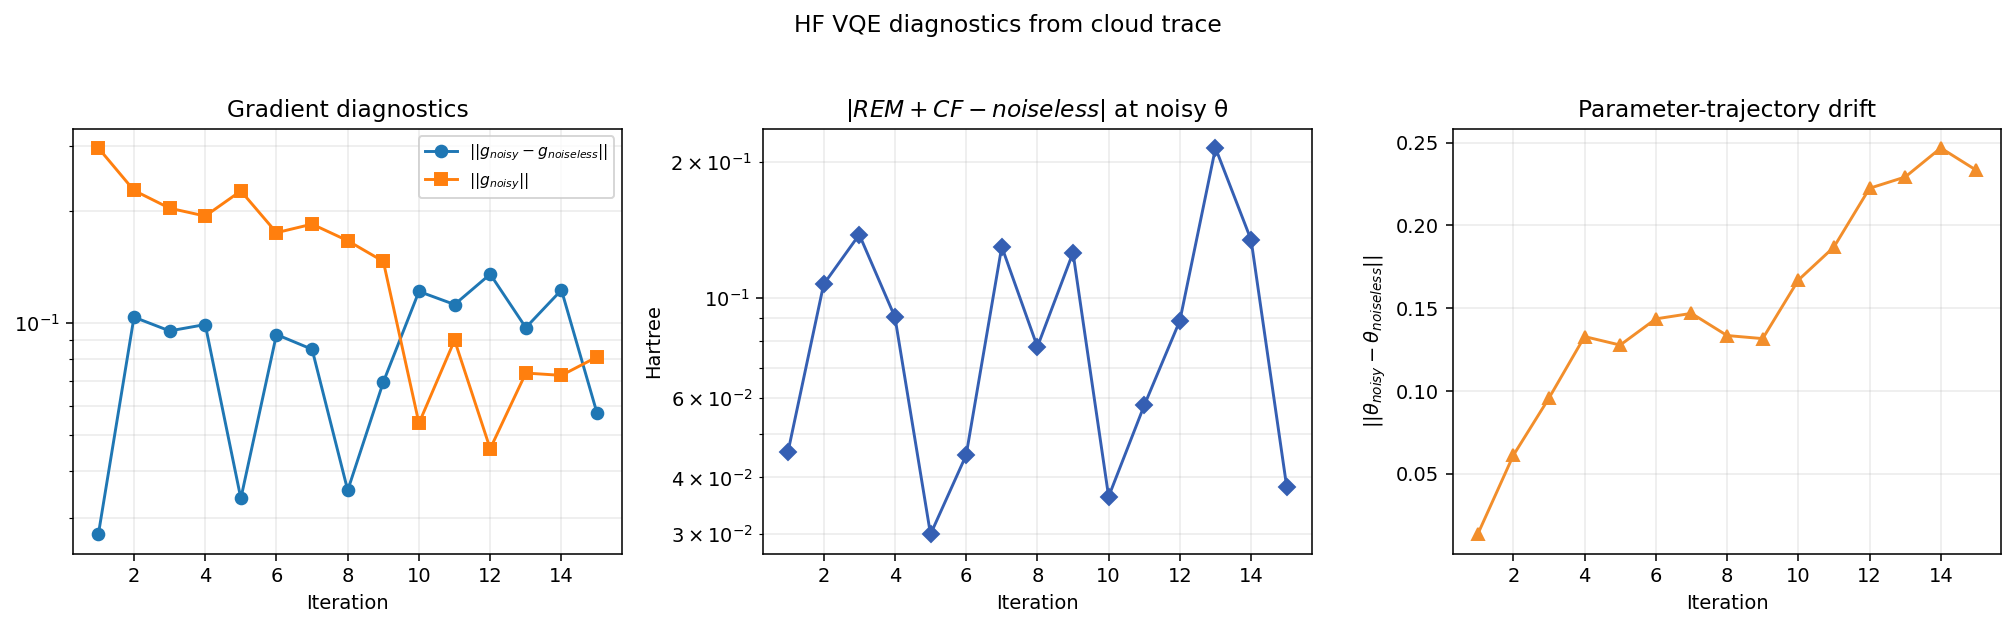

Measurement cost summary
  total CDR calls       : 107
  energy evals/call     : 31
  shots/eval            : 8192
  estimated total shots : 27,172,864
  calls by stage        : {'final': 1, 'init': 1, 'main_grad': 90, 'main_post': 15, 'noiseless_track': 32, 'total': 107, 'warmup': 0}


In [4]:
# --- Extra VQE diagnostics saved by the cloud run ---
if vqe_results is None or not vqe_results.get("trace"):
    print("No VQE trace diagnostics found in", RUN_DIR)
else:
    trace = vqe_results["trace"]
    it = as_float_array(trace, "iter")
    grad_diff = as_float_array(trace, "grad_diff")
    grad_norm = as_float_array(trace, "grad_noisy_norm")
    theta_diff = as_float_array(trace, "theta_diff")
    e_bias = as_float_array(trace, "e_bias")

    fig, axes = plt.subplots(1, 3, figsize=(14.5, 4.3))

    axes[0].plot(it, grad_diff, marker="o", lw=1.5, label=r"$||g_{noisy}-g_{noiseless}||$")
    axes[0].plot(it, grad_norm, marker="s", lw=1.5, label=r"$||g_{noisy}||$")
    axes[0].set_yscale("log")
    axes[0].set_xlabel("Iteration")
    axes[0].set_title("Gradient diagnostics")
    axes[0].grid(True, which="both", alpha=0.25)
    axes[0].legend(fontsize=8)

    axes[1].plot(it, e_bias, marker="D", color="#355fb3", lw=1.5)
    axes[1].set_yscale("log")
    axes[1].set_xlabel("Iteration")
    axes[1].set_ylabel("Hartree")
    axes[1].set_title(r"$|REM+CF - noiseless|$ at noisy θ")
    axes[1].grid(True, which="both", alpha=0.25)

    axes[2].plot(it, theta_diff, marker="^", color="#f28e2b", lw=1.5)
    axes[2].set_xlabel("Iteration")
    axes[2].set_ylabel(r"$||\theta_{noisy}-\theta_{noiseless}||$")
    axes[2].set_title("Parameter-trajectory drift")
    axes[2].grid(True, alpha=0.25)

    fig.suptitle(f"{molecule} VQE diagnostics from cloud trace", y=1.03)
    fig.tight_layout()
    plt.show()

    cost = vqe_results.get("cost_model", {})
    counts = vqe_results.get("counts", {})
    if cost:
        print("Measurement cost summary")
        print(f"  total CDR calls       : {cost.get('total_cdr_calls', counts.get('total'))}")
        print(f"  energy evals/call     : {cost.get('energy_evals_per_cdr_call')}")
        print(f"  shots/eval            : {cost.get('num_shots_per_eval')}")
        print(f"  estimated total shots : {cost.get('total_shots_est'):,}")
        print(f"  calls by stage        : {counts}")


CMX status: complete sweep without error bars (3 multipliers; variance_repeats < 2)
CMX/CME variance and shot-budget results: HF_bond_2.2


,H2/H3 multiplier,variance repeats,has error bar,H shots/repeat,H2 shots/repeat,H3 shots/repeat,<H> noiseless (Eh),<H2> noiseless (Eh^2),<H3> noiseless (Eh^3),E_cme noiseless (Eh),...,Var[E_cme] (Eh^2),sigma propagated (Eh),sigma empirical (Eh),E_cme - 1 sigma (Eh),E_cme - 2 sigma (Eh),E_gs (Eh),|shot CME - GS| (mEh),|CME-1sigma - GS| (mEh),|CME-2sigma - GS| (mEh),shot CME below chem. acc. (1.6 mEh)
0,5,1,False,40960,40960,40960,-98.437392,9689.933337,-953854.368081,-98.456504,...,NaN,NaN,NaN,NaN,NaN,-98.458424,19.981140,NaN,NaN,False
1,10,1,False,81920,81920,81920,-98.437392,9689.933337,-953854.368081,-98.456504,...,NaN,NaN,NaN,NaN,NaN,-98.458424,35.912462,NaN,NaN,False
2,20,1,False,163840,163840,163840,-98.437392,9689.933337,-953854.368081,-98.456504,...,NaN,NaN,NaN,NaN,NaN,-98.458424,22.726291,NaN,NaN,False


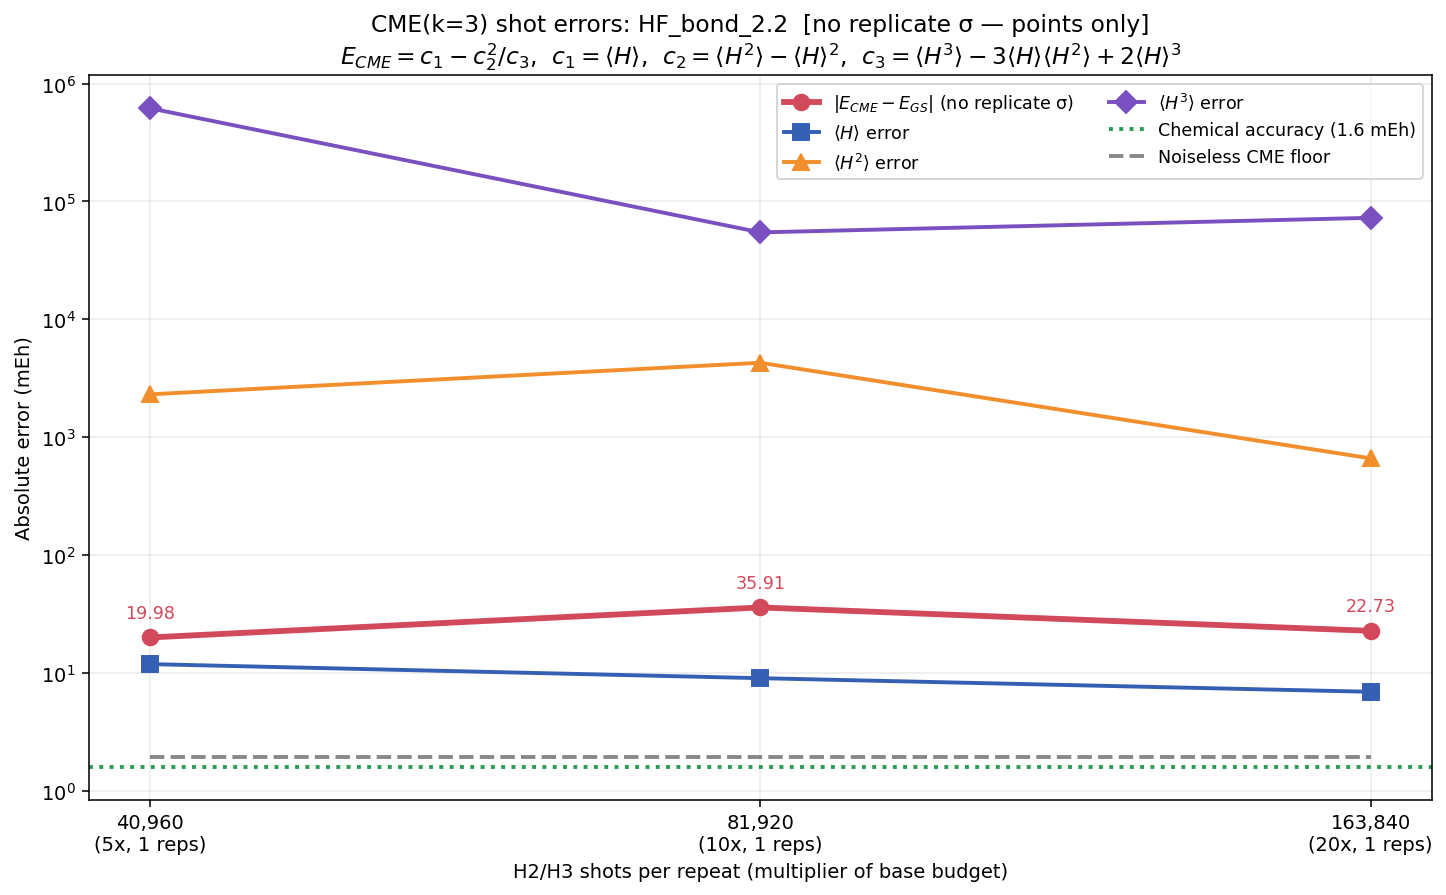

In [5]:
# --- CMX/CME energy error table when sweep data exists ---
import pandas as pd
from IPython.display import display


def _safe_float(value, default=np.nan):
    try:
        if value is None:
            return float(default)
        return float(value)
    except (TypeError, ValueError):
        return float(default)


def empirical_sigma_eh(result):
    """Empirical σ from saved field, else std of E_cme_replicates (ddof=1)."""
    emp = _safe_float(result.get("E_cme_empirical_sigma"))
    if np.isfinite(emp) and emp >= 0:
        return emp
    reps = result.get("E_cme_replicates") or []
    if isinstance(reps, list) and len(reps) >= 2:
        return float(np.std(np.asarray(reps, dtype=float), ddof=1))
    return np.nan


if not cme_by_multiplier:
    print("No CMX/CME sweep results found in", RUN_DIR)
    print("  (VQE-only / incomplete run is OK — re-run this cell after CMX finishes.)")
else:
    print(f"CMX status: {cmx_status}")
    rows = []
    for mult, result in sorted(cme_by_multiplier.items()):
        shots = result.get("shots") or {}
        moments = result.get("moments") or {}
        e_cme = _safe_float(result.get("E_cme_shots"))
        e_cme_noiseless = _safe_float(result.get("E_cme_noiseless"))
        e_gs = _safe_float(result.get("e_gs"), e_ref if e_ref is not None else np.nan)
        variance = _safe_float(result.get("E_cme_variance"))
        sigma = _safe_float(result.get("E_cme_sigma"))
        if not np.isfinite(sigma) and np.isfinite(variance) and variance >= 0:
            sigma = float(np.sqrt(variance))
        e_minus_1sigma = _safe_float(
            result.get("E_cme_minus_1sigma"),
            e_cme - sigma if np.isfinite(e_cme) and np.isfinite(sigma) else np.nan,
        )
        e_minus_2sigma = _safe_float(
            result.get("E_cme_minus_2sigma"),
            e_cme - 2.0 * sigma if np.isfinite(e_cme) and np.isfinite(sigma) else np.nan,
        )
        empirical_sigma = empirical_sigma_eh(result)
        reps = result.get("E_cme_replicates") or []
        n_reps = len(reps) if isinstance(reps, list) else 0
        repeats = int(result.get("variance_repeats") or n_reps or 1)
        err_gs = abs(e_cme - e_gs) if np.isfinite(e_cme) and np.isfinite(e_gs) else np.nan
        noiseless_err_gs = (
            abs(e_cme_noiseless - e_gs)
            if np.isfinite(e_cme_noiseless) and np.isfinite(e_gs)
            else np.nan
        )

        def _moment(key, field):
            block = moments.get(key) or {}
            return _safe_float(block.get(field))

        base_h = int(shots.get("H") or 0)
        h2 = int(shots.get("H2") or (base_h * mult if base_h else 0))
        h3 = int(shots.get("H3") or (base_h * mult if base_h else 0))

        rows.append(
            {
                "H2/H3 multiplier": mult,
                "variance repeats": repeats,
                "has error bar": cmx_entry_has_errorbar(result),
                "H shots/repeat": base_h,
                "H2 shots/repeat": h2,
                "H3 shots/repeat": h3,
                "<H> noiseless (Eh)": _moment("H", "noiseless"),
                "<H2> noiseless (Eh^2)": _moment("H2", "noiseless"),
                "<H3> noiseless (Eh^3)": _moment("H3", "noiseless"),
                "E_cme noiseless (Eh)": e_cme_noiseless,
                "|noiseless CME - GS| (mEh)": noiseless_err_gs * 1e3,
                "E_cme shots (Eh)": e_cme,
                "Var[E_cme] (Eh^2)": variance,
                "sigma propagated (Eh)": sigma,
                "sigma empirical (Eh)": empirical_sigma,
                "E_cme - 1 sigma (Eh)": e_minus_1sigma,
                "E_cme - 2 sigma (Eh)": e_minus_2sigma,
                "E_gs (Eh)": e_gs,
                "|shot CME - GS| (mEh)": err_gs * 1e3,
                "|CME-1sigma - GS| (mEh)": abs(e_minus_1sigma - e_gs) * 1e3
                if np.isfinite(e_minus_1sigma) and np.isfinite(e_gs)
                else np.nan,
                "|CME-2sigma - GS| (mEh)": abs(e_minus_2sigma - e_gs) * 1e3
                if np.isfinite(e_minus_2sigma) and np.isfinite(e_gs)
                else np.nan,
                "shot CME below chem. acc. (1.6 mEh)": bool(
                    np.isfinite(err_gs) and err_gs <= 1.6e-3
                ),
            }
        )

    cme_error_table = pd.DataFrame(rows)
    print(f"CMX/CME variance and shot-budget results: {RUN_DIR.name}")
    if pending_mults:
        print(f"  Note: incomplete sweep — pending multipliers {pending_mults}")
    display(cme_error_table)

    # Single log-log plot: CMX error (+ optional empirical σ bars) and moment errors.
    shot_counts = cme_error_table["H2 shots/repeat"].to_numpy(dtype=float)
    multipliers = cme_error_table["H2/H3 multiplier"].to_numpy(dtype=int)
    repeats = cme_error_table["variance repeats"].to_numpy(dtype=int)
    shot_tick_labels = [
        f"{int(s):,}\n({m}x, {r} reps)"
        for s, m, r in zip(shot_counts, multipliers, repeats)
    ]

    cme_meh = cme_error_table["|shot CME - GS| (mEh)"].to_numpy(dtype=float)
    cme_noiseless_meh = cme_error_table["|noiseless CME - GS| (mEh)"].to_numpy(dtype=float)
    emp_sigma_meh = cme_error_table["sigma empirical (Eh)"].to_numpy(dtype=float) * 1e3
    can_err = cme_error_table["has error bar"].to_numpy(dtype=bool)

    moment_errors_meh = {key: [] for key in ("H", "H2", "H3")}
    for mult, entry in sorted(cme_by_multiplier.items()):
        source = entry.get("moment_source", "cdr_rem")
        moments = entry.get("moments") or {}
        for key in ("H", "H2", "H3"):
            block = moments.get(key) or {}
            measured = _safe_float(block.get(source))
            noiseless = _safe_float(block.get("noiseless"))
            if np.isfinite(measured) and np.isfinite(noiseless):
                moment_errors_meh[key].append(abs(measured - noiseless) * 1e3)
            else:
                moment_errors_meh[key].append(np.nan)

    fig, ax = plt.subplots(figsize=(10.5, 6.5))

    # CME points: error bars only where replicate σ is available.
    if np.any(can_err):
        yerr = np.where(can_err, emp_sigma_meh, np.nan)
        ax.errorbar(
            shot_counts,
            cme_meh,
            yerr=yerr,
            fmt="o-",
            markersize=8,
            linewidth=3.0,
            color="#d1495b",
            ecolor="#d1495b",
            elinewidth=1.5,
            capsize=4,
            label=r"$|E_{CME} - E_{GS}|$ (± emp. σ)",
        )
        if np.any(~can_err):
            ax.plot(
                shot_counts[~can_err],
                cme_meh[~can_err],
                "o",
                markersize=8,
                color="#d1495b",
                label=r"$|E_{CME} - E_{GS}|$ (no σ)",
            )
    else:
        ax.plot(
            shot_counts,
            cme_meh,
            marker="o",
            markersize=8,
            linewidth=3.0,
            linestyle="-",
            color="#d1495b",
            label=r"$|E_{CME} - E_{GS}|$ (no replicate σ)",
        )

    series = [
        (moment_errors_meh["H"], "s", "#355fb3", 2.0, "-", r"$\langle H \rangle$ error"),
        (moment_errors_meh["H2"], "^", "#f28e2b", 2.0, "-", r"$\langle H^2 \rangle$ error"),
        (moment_errors_meh["H3"], "D", "#7a4fbf", 2.0, "-", r"$\langle H^3 \rangle$ error"),
    ]
    for values, marker, color, lw, linestyle, label in series:
        ax.plot(
            shot_counts,
            values,
            marker=marker,
            markersize=8,
            linewidth=lw,
            linestyle=linestyle,
            color=color,
            label=label,
        )

    ax.axhline(
        1.6,
        color="#2a9d55",
        linestyle=":",
        linewidth=2,
        label="Chemical accuracy (1.6 mEh)",
    )
    ax.plot(
        shot_counts,
        cme_noiseless_meh,
        linestyle="--",
        linewidth=2,
        color="#888888",
        label="Noiseless CME floor",
    )

    for x, meh in zip(shot_counts, cme_meh):
        if not np.isfinite(meh):
            continue
        ax.annotate(
            f"{meh:.2f}",
            (x, meh),
            xytext=(0, 10),
            textcoords="offset points",
            ha="center",
            fontsize=9,
            color="#d1495b",
        )

    ax.set_xscale("log", base=2)
    ax.set_yscale("log")
    ax.set_xticks(shot_counts)
    ax.set_xticklabels(shot_tick_labels)
    ax.minorticks_off()
    ax.set_xlabel("H2/H3 shots per repeat (multiplier of base budget)")
    ax.set_ylabel("Absolute error (mEh)")
    title_extra = ""
    if pending_mults:
        title_extra = f"  [incomplete: pending {pending_mults}]"
    elif not np.any(can_err):
        title_extra = "  [no replicate σ — points only]"
    ax.set_title(
        f"CME(k=3) shot errors: {RUN_DIR.name}{title_extra}\n"
        r"$E_{CME} = c_1 - c_2^2/c_3$,  "
        r"$c_1 = \langle H \rangle$,  "
        r"$c_2 = \langle H^2 \rangle - \langle H \rangle^2$,  "
        r"$c_3 = \langle H^3 \rangle - 3\langle H \rangle\langle H^2 \rangle + 2\langle H \rangle^3$"
    )
    ax.grid(True, which="both", alpha=0.25)
    ax.legend(fontsize=9, loc="best", ncol=2)
    fig.tight_layout()
    plt.show()


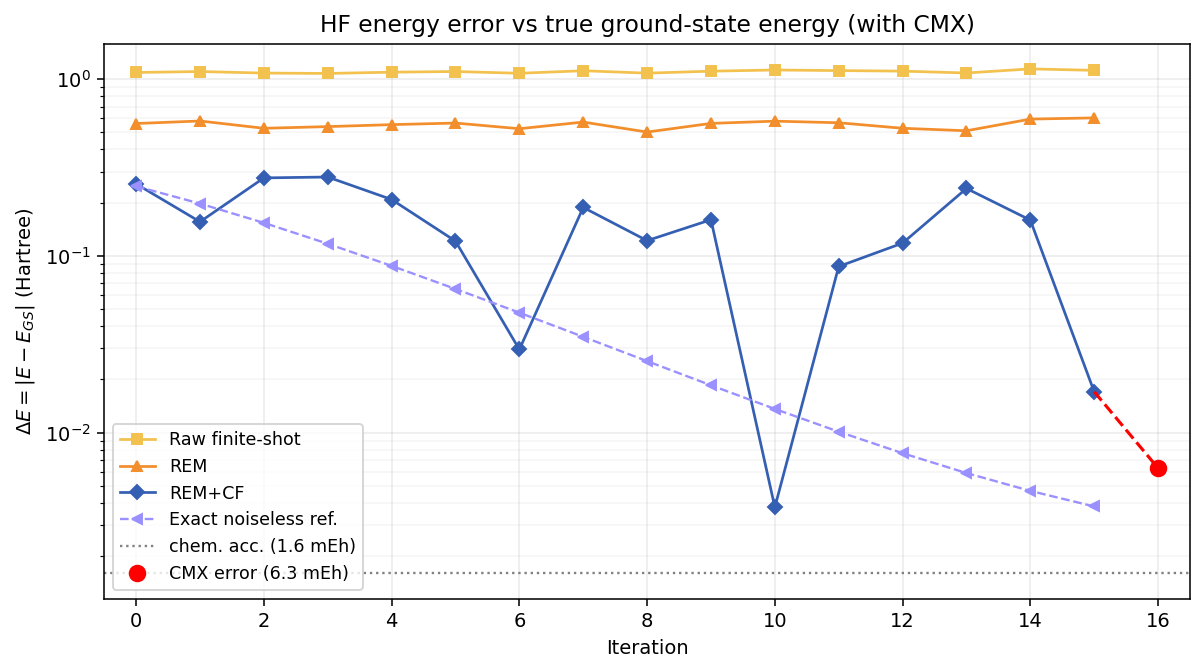

In [8]:
# --- VQE error plot + optional CMX point after final REM+CF ---
# Set CMX absolute error here (millihartree).
cmx_error_meh = 6.3
# If True, draw red dashed connector + CMX marker after final REM+CF.
show_cmx_endpoint = True

if vqe_results is None:
    print("No VQE results found in", RUN_DIR)
elif e_ref is None:
    print("Skipping plot: ground-state reference unavailable for", RUN_DIR.name)
else:
    ec = vqe_results["energy_curves"]
    xs = as_float_array(ec, "iter")
    raw = as_float_array(ec, "raw_eh")
    rem = as_float_array(ec, "rem_eh")
    cf = as_float_array(ec, "rem_cf_eh")
    nls = as_float_array(ec, "noiseless_eh")

    style_raw = dict(color="#f2c14e", marker="s", ms=5, lw=1.4, label="Raw finite-shot")
    style_rem = dict(color="#f28e2b", marker="^", ms=5, lw=1.4, label="REM")
    style_cf = dict(color="#355fb3", marker="D", ms=4.8, lw=1.4, label="REM+CF")
    style_nls = dict(color="#9a90ff", marker="<", ms=5, lw=1.2, linestyle="--", label="Exact noiseless ref.")

    floor = 1e-16
    err_raw = np.maximum(np.abs(raw - e_ref), floor)
    err_rem = np.maximum(np.abs(rem - e_ref), floor)
    err_cf = np.maximum(np.abs(cf - e_ref), floor)
    err_nls = np.maximum(np.abs(nls - e_ref), floor)

    fig, ax = plt.subplots(figsize=(8.7, 4.9))
    ax.plot(xs, err_raw, **style_raw)
    ax.plot(xs, err_rem, **style_rem)
    ax.plot(xs, err_cf, **style_cf)
    ax.plot(xs, err_nls, **style_nls)
    ax.set_yscale("log")
    ax.axhline(1.6e-3, color="gray", ls=":", lw=1.2, label="chem. acc. (1.6 mEh)")

    x_right = float(xs.max())
    if show_cmx_endpoint:
        cmx_error_eh = float(cmx_error_meh) * 1e-3
        x_final = float(xs[-1])
        y_final_cf = float(err_cf[-1])
        x_cmx = x_final + 1.0
        # Red dashed connector from final REM+CF → CMX point, then a red marker.
        ax.plot(
            [x_final, x_cmx],
            [y_final_cf, cmx_error_eh],
            color="red",
            ls="--",
            lw=1.6,
            zorder=5,
        )
        ax.plot(
            x_cmx,
            cmx_error_eh,
            color="red",
            marker="o",
            ms=8,
            linestyle="None",
            zorder=6,
            label=f"CMX error ({cmx_error_meh:g} mEh)",
        )
        x_right = x_cmx

    ax.set_xlim(xs.min() - 0.5, x_right + 0.5)
    ax.set_xlabel("Iteration")
    ax.set_ylabel(r"$\Delta E = |E - E_{GS}|$ (Hartree)")
    title = f"{molecule} energy error vs true ground-state energy"
    if show_cmx_endpoint:
        title += " (with CMX)"
    ax.set_title(title)
    ax.grid(True, which="major", alpha=0.25)
    ax.grid(True, which="minor", alpha=0.12)
    ax.legend(loc="best", fontsize=9)
    fig.tight_layout()
    plt.show()
 

In [7]:
# --- Total shots: VQE + best CMX/CME multiplier point ---
vqe_shots = None
if vqe_results is not None:
    cost = vqe_results.get("cost_model") or {}
    vqe_shots = cost.get("total_shots_est")
    if vqe_shots is None and cost.get("total_cdr_calls") and cost.get("shots_per_cdr_call"):
        vqe_shots = int(cost["total_cdr_calls"]) * int(cost["shots_per_cdr_call"])

evals_per_cdr = None
if vqe_results is not None:
    evals_per_cdr = (vqe_results.get("cost_model") or {}).get("energy_evals_per_cdr_call")
if evals_per_cdr is None:
    evals_per_cdr = 1  # fall back to raw moment shots if CDR cost model is missing

best_mult = None
best_result = None
best_err = None
if cme_by_multiplier:
    for mult, result in cme_by_multiplier.items():
        e_cme = result.get("E_cme_shots")
        e_gs = result.get("e_gs", e_ref)
        if e_cme is None or e_gs is None:
            continue
        err = abs(float(e_cme) - float(e_gs))
        if best_err is None or err < best_err:
            best_err = err
            best_mult = int(mult)
            best_result = result

print(f"Total shot budget for {RUN_DIR.name}")
print("-" * 48)
print(f"CMX status: {cmx_status}")

if vqe_shots is None:
    print("VQE shots: unavailable (no vqe_results / cost_model)")
else:
    print(f"VQE total shots (est.): {int(vqe_shots):,}")

if best_result is None:
    print("Best CMX point: unavailable (no CMX sweep)")
    cmx_shots = None
else:
    shots_map = best_result.get("shots") or {}
    reps_list = best_result.get("E_cme_replicates") or []
    n_reps = len(reps_list) if isinstance(reps_list, list) else 0
    repeats = int(best_result.get("variance_repeats") or n_reps or 1)
    h = int(shots_map.get("H") or 0)
    h2 = int(shots_map.get("H2") or (h * best_mult if h else 0))
    h3 = int(shots_map.get("H3") or (h * best_mult if h else 0))
    moment_shots_per_repeat = h + h2 + h3
    # Each <H^k> measurement uses the CDR pipeline, so scale like VQE cost_model.
    cmx_shots = int(moment_shots_per_repeat * repeats * int(evals_per_cdr))
    print(
        f"Best CMX point: {best_mult}x  "
        f"(|E_CME - E_GS| = {best_err * 1e3:.4f} mEh)"
        + ("  [has emp. σ]" if cmx_entry_has_errorbar(best_result) else "  [no emp. σ]")
    )
    print(
        f"  moment shots/repeat: H={h:,}, "
        f"H2={h2:,}, H3={h3:,}  "
        f"(repeats={repeats})"
    )
    print(f"  CDR energy evals/call: {int(evals_per_cdr)}")
    print(f"CMX shots at best point (est.): {cmx_shots:,}")
    if pending_mults:
        print(f"  Note: sweep still pending multipliers {pending_mults}")

if vqe_shots is not None and cmx_shots is not None:
    total = int(vqe_shots) + int(cmx_shots)
    print("-" * 48)
    print(f"VQE + best CMX total shots (est.): {total:,}")
elif vqe_shots is not None:
    print("-" * 48)
    print(f"VQE-only total shots (est.): {int(vqe_shots):,}")


Total shot budget for HF_bond_2.2
------------------------------------------------
CMX status: complete sweep without error bars (3 multipliers; variance_repeats < 2)
VQE total shots (est.): 27,172,864
Best CMX point: 5x  (|E_CME - E_GS| = 19.9811 mEh)  [no emp. σ]
  moment shots/repeat: H=40,960, H2=40,960, H3=40,960  (repeats=1)
  CDR energy evals/call: 31
CMX shots at best point (est.): 3,809,280
------------------------------------------------
VQE + best CMX total shots (est.): 30,982,144
